In [2]:


import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [3]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

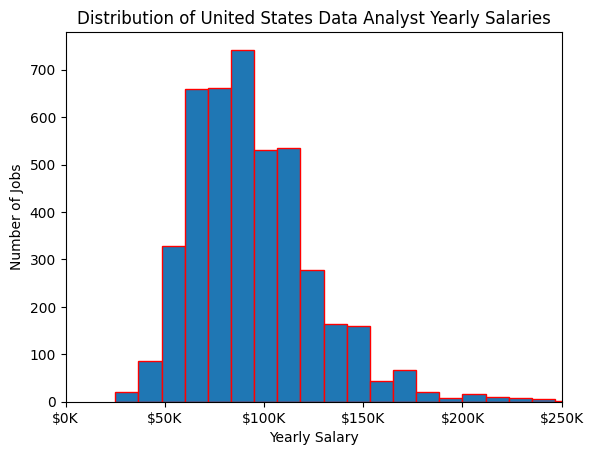

In [8]:
df_DA_US['salary_year_avg'].plot(kind='hist',bins=30,edgecolor='red')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

<span style ="color:green;font-width:bold; font-size:32px;"> Practice Prompts </span>

In [ ]:
# Problem Statement:
# Create a histogram to show the distribution of hourly salaries (use salary_hour_avg column) for Data Scientist job postings:

# Create a new DataFrame called df_DS to filter out 'Data Scientist' jobs.
# Customize the plot by setting the number of bins to 40 and the bar color to blue.
# Label the x-axis as 'Hourly Salary' and the y-axis as 'Number of Jobs'.

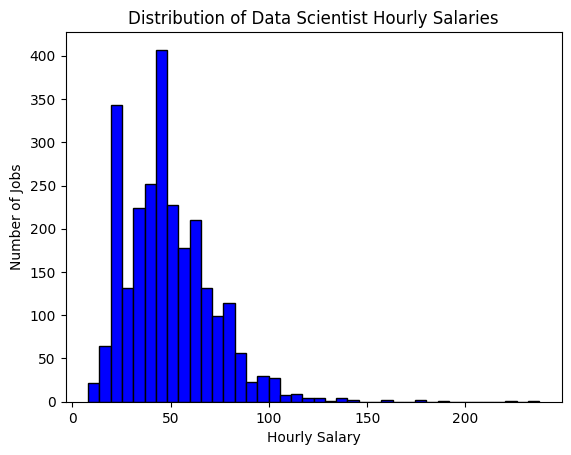

In [9]:
df_DS = df[df['job_title_short'] == 'Data Scientist'].copy()
df_DS = df_DS.dropna(subset=['salary_hour_avg'])

# Plot the histogram
df_DS['salary_hour_avg'].plot(kind='hist', bins=40, color='blue', edgecolor='black')
plt.xlabel('Hourly Salary')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Data Scientist Hourly Salaries')
plt.show()

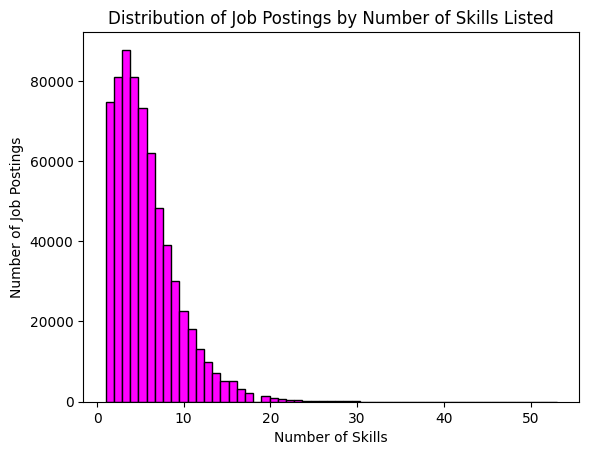

In [11]:
# Problem Statement:
# Create a histogram to show the distribution of job postings by the number of skills listed using the job_skills column:

# Create a new DataFrame called df_skills to filter out job postings with non-null job_skills.
# Customize the plot by setting the number of bins to 55, the bar color to 'magenta'
# Add a title 'Distribution of Job Postings by Number of Skills Listed'.
# Label the x-axis as 'Number of Skills' and the y-axis as 'Number of Job Postings'.

df_skills = df.dropna(subset=['job_skills']).copy()
df_skills['num_skills'] = df_skills['job_skills'].apply(len)

# Plot the histogram
df_skills['num_skills'].plot(kind='hist', bins=55, color='magenta', edgecolor='black')
plt.xlabel('Number of Skills')
plt.ylabel('Number of Job Postings')
plt.title('Distribution of Job Postings by Number of Skills Listed')
plt.show()


In [ ]:
# Problem Statement:
# Create a histogram to show the distribution of average yearly salaries (salary_year_avg) for Data Engineer job postings:

# Create a new DataFrame called df_DE to filter out 'Data Engineer' jobs.
# Customize the plot by setting the number of bins to 50, the bar color to red
# Add annotations for the mean and median salaries, using plt.axvline(); for the parameters specify:
# color: 'blue'/'green'
# linestyle: 'dashed'
# label: e.g., f'Mean: ${mean_salary:,.0f}'
# Label the x-axis as 'Yearly Salary' and the y-axis as 'Number of Jobs'.

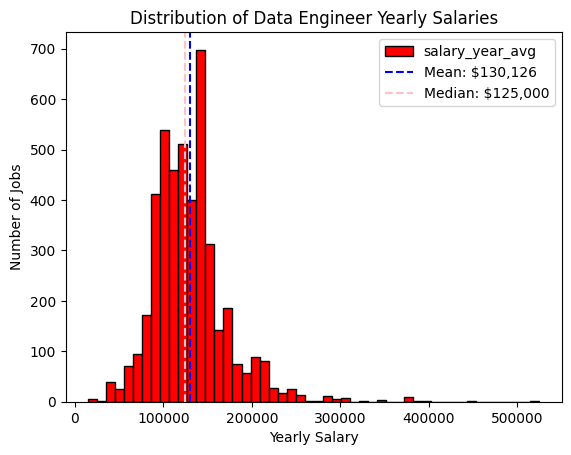

In [13]:

# Filter out the data
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()
df_DE = df_DE.dropna(subset=['salary_year_avg'])

# Get mean and median
mean_salary = df_DE['salary_year_avg'].mean()
median_salary = df_DE['salary_year_avg'].median()

# Plot the histogram
df_DE['salary_year_avg'].plot(kind='hist', bins=50, color='red', edgecolor='black')
plt.axvline(mean_salary, color='blue', linestyle='dashed', label=f'Mean: ${mean_salary:,.0f}')
plt.axvline(median_salary, color='pink', linestyle='dashed', label=f'Median: ${median_salary:,.0f}')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Data Engineer Yearly Salaries')
plt.legend()
plt.show()